

# Training E. coli adage models for GLEAn

#### Georgia Doing, <doingg@union.edu>

#### May 11, 2026

This notebook trains adage models on E. coli a couple datasets with 
various hyperparameter choices in order to visualize training dynamics
on training and validation loss as well and hidden layer weight
distributions. 

#### Outline

1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data
3. Train some models with hyperparameters from previous search
4. Plot training loss over epochs
5. Plot weight distributions of final models



### 1. Loading classes, modules

In [1]:
# for adage models
from adage import Adage as ad
from adage import SeqAdage

# for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# misc
#from scipy.stats import hypergeom
#import csv
#import random
import time
import tensorflow as tf


2026-05-11 16:41:42.084067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 16:41:42.097037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778532102.110553 1471507 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778532102.114353 1471507 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778532102.124527 1471507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
True


2026-05-11 16:41:50.004960: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Plotting training data distributions

Here we are looking at two training datasets. The first only has genes
in MG1655 and the second has genes in either MG1655 or a couple isolates
of interest (to include eloD genes).

### MG1655 genes

4272 16150


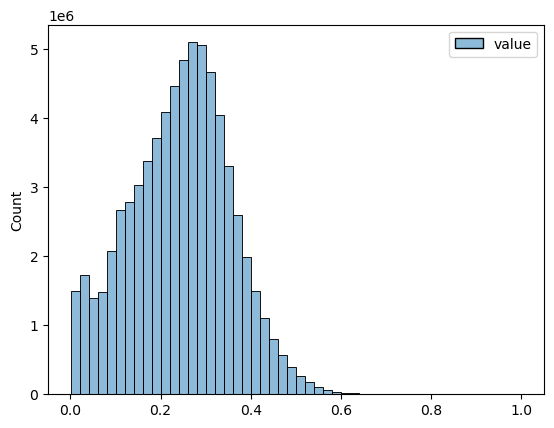

In [3]:
all_comp = pd.read_csv('../data_files/ecmg_lcn01.csv', index_col = 0) 
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(pd.melt(all_comp), bins = 50)

### MG1655+ genes

In [ ]:
all_comp = pd.read_csv('../data_files/ecmgp_lcn01.csv', index_col = 0) 
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(pd.melt(all_comp), bins = 50)

6390 16122


## 3. Train models

In a previous hyperparameter seach I landed on the following:

* enccoding dimension: 459
* L1 normalizaion: 0
* L2 normalization: 0
* activation functios: tanh
* tied: True
* epochs: 50
* initialization: glorot_uniform
* batch_size: 15
* dropout: 0
* momentum: 0.6
* learning rate: 0.5

In [ ]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv","ecmgp_lcn01.csv"]
model_dict_post = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/ecmg_mgs_lcn01.csv',
                                                  seed=seed+100,
                                                  enc_dim = 450,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=15,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5) 
        mseq = sa.train_model()
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

In [ ]:
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

## 4. Plot training loss

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps) 
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1

## 5. Plot weight distributions

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps) 
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1